# Notebook 2: Final Clustering and Performance Evaluation

The objective of this notebook is to apply the optimal preprocessing configuration obtained from Notebook 1 and evaluate multiple clustering algorithms on the transformed dataset.

This stage focuses on:

- fitting the final feature space using the selected parameters
- comparing different clustering models
- reporting quantitative performance metrics
- producing visual outputs to support interpretation

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

## Loading Optimal Preprocessing Configuration

The best-performing hyperparameter set identified in Notebook 1 is imported from `output/best_params.csv`.
This ensures that the final clustering analysis is carried out using the most suitable preprocessing pipeline without repeating the search process.

In [11]:
# load dataset
df = pd.read_csv("data/ClimateDataBasel.csv")

# keep only numeric data
X = df.select_dtypes(include=[np.number])
X = SimpleImputer(strategy="median").fit_transform(X)

# load best params from notebook 1
data_param = Path("output/optimal_parameter_search")
best = pd.read_csv(data_param/"best_params.csv").iloc[0]

ct = float(best["corr_threshold"])
cont = float(best["contamination"])
sc = best["scaler_type"]
vt = float(best["variance_threshold"])
pv = float(best["pca_variance"])

## Applying the Preprocessing Pipeline

The same sequence used during hyperparameter exploration is applied here:

1. remove highly correlated features
2. optionally eliminate low-variance features
3. detect and remove outliers using Isolation Forest
4. scale the filtered data
5. apply PCA for dimensionality reduction

Two PCA outputs are generated:

- a full-dimensional representation for clustering
- a 2D projection used only for visualisation

This ensures consistency between the optimisation phase and the final evaluation.

In [12]:
def remove_corr(X, thr):
    df2 = pd.DataFrame(X)
    corr = df2.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop = [col for col in upper.columns if (upper[col] > thr).any()]
    return df2.drop(drop, axis=1).to_numpy()

def pick_scaler(name):
    if name == "standard":
        return StandardScaler()
    elif name == "robust":
        return RobustScaler()
    else:
        return PowerTransformer()

def plot_clusters(X2, labels, title):
    plt.figure(figsize=(6,4))
    plt.scatter(X2[:,0], X2[:,1], c=labels, s=10)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

In [13]:
# correlation filtering
X_corr = remove_corr(X, ct)

# variance threshold
if vt > 0:
    X_corr = VarianceThreshold(vt).fit_transform(X_corr)

# outlier removal
iso = IsolationForest(contamination=cont, random_state=0)
mask = iso.fit_predict(X_corr) == 1
X_clean = X_corr[mask]

# scaling
scaler = pick_scaler(sc)
X_scaled = scaler.fit_transform(X_clean)

# PCA main space
pca = PCA(n_components=pv, random_state=0)
X_pca = pca.fit_transform(X_scaled)

# PCA for plotting only (2D)
pca2 = PCA(n_components=2, random_state=0)
X_pca2 = pca2.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)

PCA shape: (1744, 4)


## KMeans Clustering

KMeans is evaluated across several values of *k* to identify the most suitable number of clusters.
The model with the highest silhouette score is selected.

For the final solution, the following metrics are reported:

- **Silhouette Score** (higher indicates better separation)
- **Davies–Bouldin Index** (lower indicates better compactness)
- **Calinski–Harabasz Score** (higher indicates better cluster structure)

A 2D PCA scatter plot is generated to illustrate the resulting cluster assignments.

KMeans best k: 2
Silhouette: 0.6800236899088042
Davies-Bouldin: 0.6429822014704192
Calinski-Harabasz: 1591.492612766868


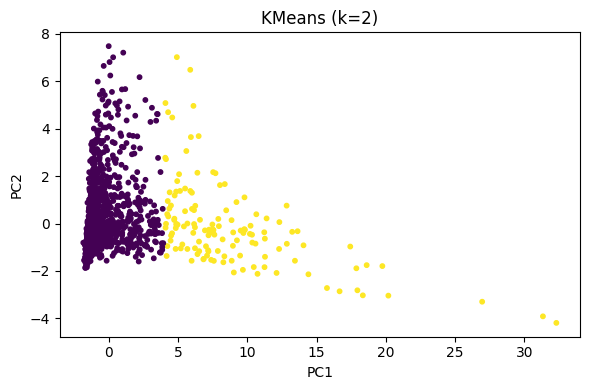

In [14]:
k_values = [2,3,4,5,6]

best_k = None
best_k_score = -1

for k in k_values:
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X_pca)
    s = silhouette_score(X_pca, labels)

    if s > best_k_score:
        best_k_score = s
        best_k = k
        best_labels_km = labels

print("KMeans best k:", best_k)
print("Silhouette:", best_k_score)

db_km = davies_bouldin_score(X_pca, best_labels_km)
ch_km = calinski_harabasz_score(X_pca, best_labels_km)

print("Davies-Bouldin:", db_km)
print("Calinski-Harabasz:", ch_km)

plot_clusters(X_pca2, best_labels_km, f"KMeans (k={best_k})")

## DBSCAN Clustering

DBSCAN is tested using a small range of `eps` and `min_samples` values to identify a stable configuration.
Only non-noise samples are included in the metric calculation to avoid misleading scores.

The same evaluation metrics are reported, along with a visualisation of the detected core clusters and noise points.

DBSCAN best params: (1.0, 10)
Silhouette: 0.6731473428997874
Davies-Bouldin: 0.3153523177718332
Calinski-Harabasz: 210.99489551109173


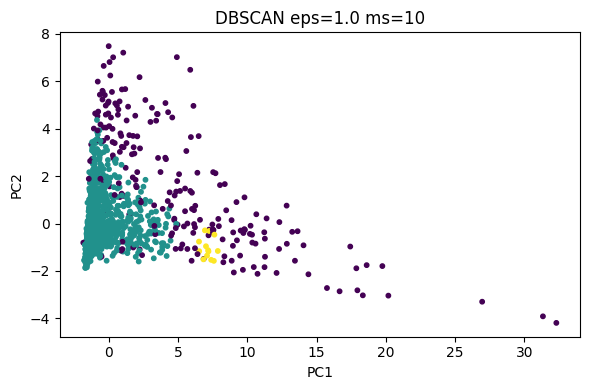

In [15]:
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [5, 10]

best_db = None
best_db_score = -1
best_labels_db = None

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X_pca)
        labels = db.labels_

        core = labels != -1
        if core.sum() < 2:
            continue

        s = silhouette_score(X_pca[core], labels[core])

        if s > best_db_score:
            best_db_score = s
            best_db = (eps, ms)
            best_labels_db = labels

print("DBSCAN best params:", best_db)
print("Silhouette:", best_db_score)

core = best_labels_db != -1
db_db = davies_bouldin_score(X_pca[core], best_labels_db[core])
ch_db = calinski_harabasz_score(X_pca[core], best_labels_db[core])

print("Davies-Bouldin:", db_db)
print("Calinski-Harabasz:", ch_db)

plot_clusters(X_pca2, best_labels_db, f"DBSCAN eps={best_db[0]} ms={best_db[1]}")

## Gaussian Mixture Modelling (GMM)

A Gaussian Mixture Model is fitted using several component counts, and the configuration with the highest silhouette score is selected.

GMM provides a probabilistic alternative to KMeans and may capture softer or overlapping cluster boundaries.

All three performance metrics are computed, and the final cluster assignments are visualised using the 2D PCA projection.

GMM best k: 2
Silhouette: 0.20076697719293923
Davies-Bouldin: 1.541403992427514
Calinski-Harabasz: 392.53557025707613


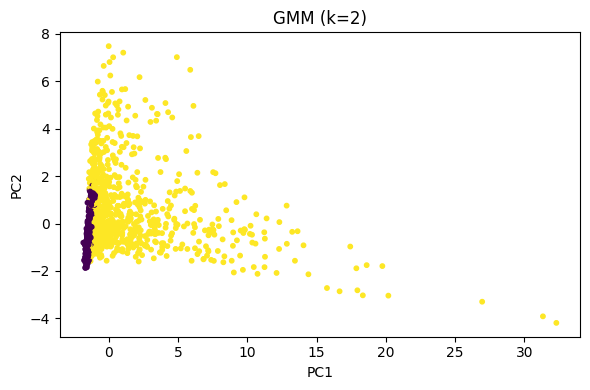

In [16]:
best_gmm_k = None
best_gmm_score = -1
best_labels_gmm = None

for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=0).fit(X_pca)
    labels = gmm.predict(X_pca)
    s = silhouette_score(X_pca, labels)

    if s > best_gmm_score:
        best_gmm_score = s
        best_gmm_k = k
        best_labels_gmm = labels

print("GMM best k:", best_gmm_k)
print("Silhouette:", best_gmm_score)

db_gmm = davies_bouldin_score(X_pca, best_labels_gmm)
ch_gmm = calinski_harabasz_score(X_pca, best_labels_gmm)

print("Davies-Bouldin:", db_gmm)
print("Calinski-Harabasz:", ch_gmm)

plot_clusters(X_pca2, best_labels_gmm, f"GMM (k={best_gmm_k})")

## Result Recording and Storage

Once all clustering models have been evaluated:

- the complete performance summary is saved as `output/final_output/model_scores_summary.csv`

These outputs provide the basis for comparing model performance and will support interpretation and reporting.

In [17]:
summary = pd.DataFrame({
    "model": ["KMeans", "DBSCAN", "GMM"],
    "silhouette": [best_k_score, best_db_score, best_gmm_score],
    "davies_bouldin": [db_km, db_db, db_gmm],
    "calinski_harabasz": [ch_km, ch_db, ch_gmm]
})

output_dir = Path("output/final_output")
summary.to_csv(output_dir/"model_scores_summary.csv", index=False)
summary

,model,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,0.680024,0.642982,1591.492613
1,DBSCAN,0.673147,0.315352,210.994896
2,GMM,0.200767,1.541404,392.535570


## Visualisation of Model Performance

A combined subplot is used to compare the three evaluation metrics across all models.
Score labels are added to assist interpretation.

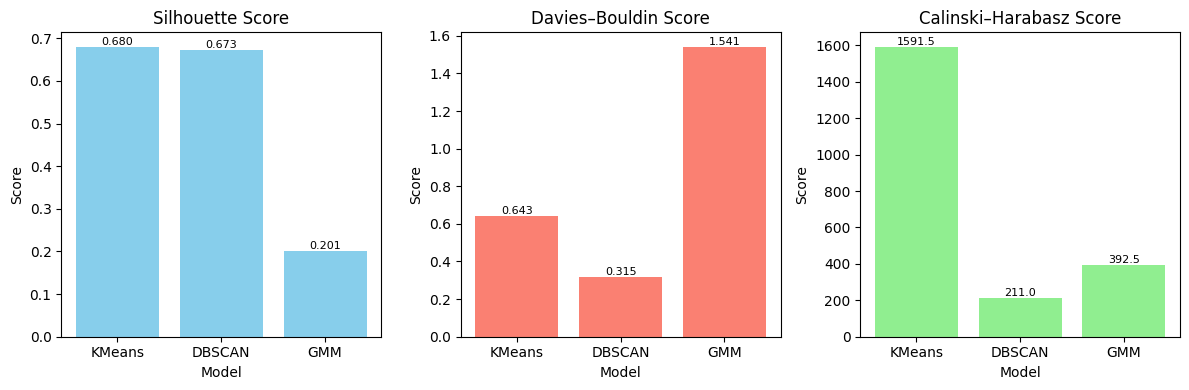

In [19]:
plt.figure(figsize=(12,4))

# --- Silhouette ---
plt.subplot(1, 3, 1)
bars1 = plt.bar(summary["model"], summary["silhouette"], color="skyblue")
plt.title("Silhouette Score")
plt.ylabel("Score")
plt.xlabel("Model")

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}", ha='center', va='bottom', fontsize=8)

# --- Davies–Bouldin ---
plt.subplot(1, 3, 2)
bars2 = plt.bar(summary["model"], summary["davies_bouldin"], color="salmon")
plt.title("Davies–Bouldin Score")
plt.ylabel("Score")
plt.xlabel("Model")

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}", ha='center', va='bottom', fontsize=8)

# --- Calinski–Harabasz ---
plt.subplot(1, 3, 3)
bars3 = plt.bar(summary["model"], summary["calinski_harabasz"], color="lightgreen")
plt.title("Calinski–Harabasz Score")
plt.ylabel("Score")
plt.xlabel("Model")

for bar in bars3:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.1f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

plt.savefig(output_dir / "model_scores_subplots_labeled.png")
plt.close()

|## Conclusion

This notebook completes the clustering stage of the analysis.
By applying the optimal preprocessing configuration, three clustering models were evaluated and compared using standard quantitative metrics and visual inspection.

The results highlight differences in cluster structure across algorithms, providing a basis for selecting the most appropriate model for further interpretation or downstream tasks.